5


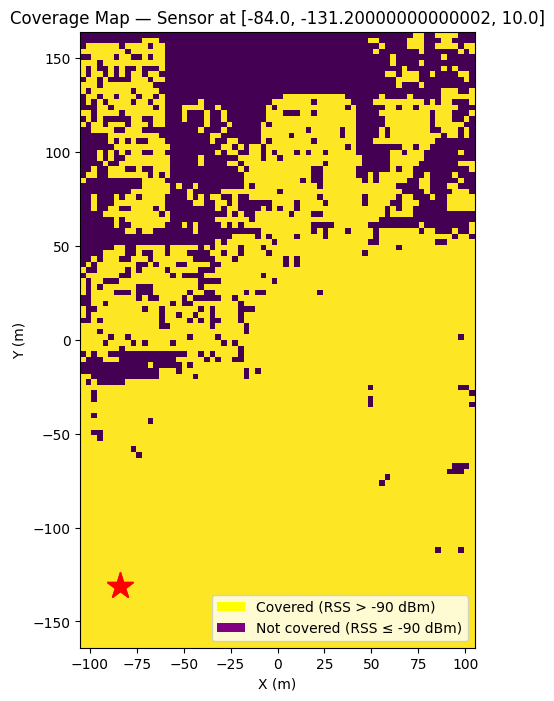

Total samples in dataset: 5
Coverage: 5907 / 7700 cells (76.7%)


In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("dataset.json") as f:
    dataset = json.load(f)

# Pick a sample to visualize
idx = 0  # change this to look at different sensors
sample = dataset[idx]
print(len(dataset))

coverage_map = np.array(sample["coverage_map"])
sensor_pos = sample["sensor_pos"]

plt.figure(figsize=(10, 8))
plt.imshow(coverage_map, origin='lower', cmap='viridis',
           extent=[-105, 105, -164, 164])
plt.plot(sensor_pos[0], sensor_pos[1], 'r*', markersize=20, label=f'Sensor {sensor_pos}')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title(f'Coverage Map — Sensor at {sensor_pos}')
plt.legend()

from matplotlib.patches import Patch
# Sensor marker legend (top right)
plt.plot(sensor_pos[0], sensor_pos[1], 'r*', markersize=20, label=f'Sensor {sensor_pos}')
plt.legend(loc='upper right')

# Coverage legend (bottom right)
from matplotlib.patches import Patch
coverage_legend = [
    Patch(facecolor='yellow', label='Covered (RSS > -90 dBm)'),
    Patch(facecolor='purple', label='Not covered (RSS ≤ -90 dBm)')
]
plt.legend(handles=coverage_legend, loc='lower right')
plt.show()

print(f"Total samples in dataset: {len(dataset)}")
print(f"Coverage: {coverage_map.sum()} / {coverage_map.size} cells ({100*coverage_map.mean():.1f}%)")